# Download and fit a stellar SED

For group members using nearby stars. Install `sedkit[download]` and a Jupyter kernel first. This notebook downloads one public Gaia source, fits a single star and coeval binary, and inspects the residuals. Age is fixed to 5 Gyr and [M/H] to zero.

In [1]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
from sedkit import download, fit, plot, SED, StellarModel

## Download

The download retains catalogue quality flags, native fluxes and errors. Running it again reuses local products.

In [2]:
sed = download("1521154374020165376", cache_dir="data")
print("source:", sed.source_id)
print("parallax [mas]:", sed.parallax_mas)
print("valid XP channels:", sed.mask[:61].sum())

source: 1521154374020165376
parallax [mas]: 10.886894569449012
valid XP channels: 61


## Fit

Both hypotheses see the same absolute fluxes and quality mask. W1/W2 are held out. A larger delta means a better binary objective under these assumptions; it is not a binary probability.

In [3]:
model = StellarModel()
result = fit(sed, model=model, age_gyr=5.0, feh=0.0)
for kind in ("single", "binary"):
    r = result[kind]
    print(kind, {key: r[key] for key in ("m1", "q", "chi2", "n_fit", "converged", "at_bounds")})
print("delta:", result["delta"])

single {'m1': 0.6717311638658454, 'q': 0.0, 'chi2': 202.8513698866776, 'n_fit': 64, 'converged': True, 'at_bounds': []}
binary {'m1': 0.6771359485562095, 'q': 0.38288001750590117, 'chi2': 96.90188361657712, 'n_fit': 64, 'converged': True, 'at_bounds': ['parallax_z']}
delta: 97.02369772545211


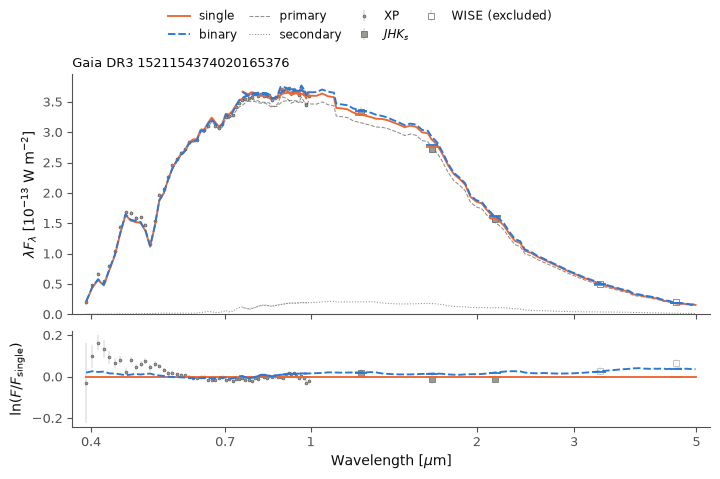

In [4]:
fig = plot(sed, result, path="real_source.png")
plt.show()

## Reuse and connect

The fitted light ratio is F_G,2/F_G,1. The signed photocentre ratio connects the stellar model to a primary-frame orbit. These values depend on PARSEC and the fitted component parameters.

In [5]:
r = result["binary"]
print("G-band flux ratio:", r["beta_g"])
print("signed a_phot/a1:", r["a_phot_over_a1"])
sed.save("data/example_sed.npz")
loaded = SED.load("data/example_sed.npz")

G-band flux ratio: 0.021013939272933765
signed a_phot/a1: 0.9256642715519422


## Try a fixed mass ratio

Fit q=0.7 and compare its objective with the free-q solution. A supported fixed-q solution should have an objective at least as large as the free-q optimum; a lower value would expose an optimiser basin that needs another start.

In [6]:
fixed = fit(sed, kind="binary", q=0.7, model=model, age_gyr=5, feh=0)
print("fixed-q minus free-q objective:", fixed["objective"] - r["objective"])

fixed-q minus free-q objective: 839.3024002295953


## Limitations

Extinction is zero. Age and metallicity are fixed here; set either to `None` to fit it. XP measurement correlations are omitted. Fitted parameters are local optima without posterior error bars. A model preference does not confirm a binary. See `docs/model.md` for support limits.

Under these fixed-age, fixed-metallicity assumptions, this example reaches the parallax constraint boundary and leaves structured XP residuals. Inspect these diagnostics before interpreting its mass ratio.